In [1]:
import os
import pandas as pd
import xlwings as xw

In [2]:
# Definición de Var globales de accesso a archivos
CODIGO_USUARIO = os.getlogin()
DIRECTORIO_LOCAL = os.getcwd().replace("\\", "/")
BASE_SELECTION = {
    "credicorp": "Credicorp/David Alonso Cuadros Negrete - PS",
    "onedrive": "OneDrive - Credicorp/Archivos de David Alonso Cuadros Negrete - PS",
}

# Directorios de información
IMPORT_PATH_CHARTBOOK = f"D:/Datos de Usuarios/{CODIGO_USUARIO}/Credicorp/Mandatos Perú - Documents/6 - Celula de RV/2 - Monitor.xlsx"

In [3]:
def import_chartbook(open_excel: bool = False, file: str = IMPORT_PATH_CHARTBOOK) -> pd.DataFrame:
    
    """
    Importar datos desde el Excel de Chartbook de Renta Variable.
    Si el archivo está abierto en Excel, se importa directamente desde allí utilizando xlwings.
    Si no está abierto, se importa desde la ruta especificada utilizando pandas.

    Parámetros:
    ----------------
    open_excel (bool): Indica si el archivo de Excel está abierto. Por defecto es False.
    
    file (str): Ruta al archivo de Excel. Por defecto es IMPORT_PATH_CHARTBOOK

    Retorna:
    ----------------
    data (pd.DataFrame): DataFrame con los datos de precios desde la hoja "Data".
    
    activos (pd.DataFrame): DataFrame con la información de los activos desde la hoja "Base".

    """
    
    data = pd.read_excel(file, skiprows=12, usecols= lambda x: x not in ["A", "B"], sheet_name="Data", engine="openpyxl")
    data = data.set_index("Fecha")    
    activos = pd.read_excel(file, skiprows=2, usecols= lambda x: x not in ["A"], sheet_name="Base", engine="openpyxl")    
    activos = activos.drop(columns=["Unnamed: 0"])
    activos = activos.set_index("Ticker")

    return data, activos

In [4]:
data, activos = import_chartbook()

d:\Datos de Usuarios\K02066\Desktop\Helpers_PS\helpers_ps\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [2]:
from helpers_ps.Grafico.graf import Graph_mtplt
from helpers_ps.Config.var_globs import PALETA_COLORES

In [6]:
data.columns.tolist()

['PX_LAST-GSXUDEFS INDEX',
 'PX_LAST-GSXUCYCL INDEX',
 'PX_LAST-RUJ INDEX',
 'PX_LAST-RUO INDEX',
 'PX_LAST-SVX INDEX',
 'PX_LAST-SGX INDEX',
 'PX_LAST-RTY INDEX',
 'PX_LAST-SPX INDEX',
 'PX_LAST-B500XM7P INDEX',
 'PX_LAST-S5COND INDEX',
 'PX_LAST-S5CONS INDEX',
 'PX_LAST-S5ENRS INDEX',
 'PX_LAST-S5MATRX INDEX',
 'PX_LAST-S5RLST INDEX',
 'PX_LAST-S5HLTH INDEX',
 'PX_LAST-S5TELS INDEX',
 'PX_LAST-S5UTIL INDEX',
 'PX_LAST-S5INDU INDEX',
 'PX_LAST-S5FINL INDEX',
 'PX_LAST-S5INFT INDEX',
 'PX_LAST-NDX INDEX',
 'PX_LAST-VIX INDEX',
 'PX_LAST-USGG10YR INDEX',
 'PX_LAST-USGG30YR INDEX',
 'PX_LAST-USGG2YR INDEX',
 'PX_LAST-DSPX INDEX',
 'PX_LAST-INDU INDEX',
 'PX_LAST-MOVE INDEX',
 'PX_LAST-PCUSEQTR INDEX',
 'PX_LAST-IMM0ENCN INDEX',
 'PX_LAST-GU731834 INDEX',
 'PX_LAST-SKEW INDEX',
 'PX_LAST-SMILE INDEX',
 'PX_LAST-MXWD INDEX',
 'PX_LAST-RIY INDEX',
 'PX_LAST-BFCIUS INDEX',
 'PX_LAST-XAU CURNCY',
 'PX_LAST-CL1 COMDTY',
 'PX_LAST-HG1 COMDTY',
 'PX_LAST-MXCA INDEX',
 'PX_LAST-MSER INDEX',
 'PX_

In [7]:
tickers = ["PX_LAST-SPX INDEX", "PX_LAST-RUO INDEX"]
data_indices_i = data[tickers]
data_indices_i

,PX_LAST-SPX INDEX,PX_LAST-RUO INDEX
Fecha,,
1996-06-04,672.56,277.813
1996-06-05,678.44,278.501
1996-06-06,673.03,275.541
1996-06-07,673.31,273.835
1996-06-08,673.31,273.835
...,...,...
2026-05-24,7473.47,1901.192
2026-05-25,7473.47,1901.192
2026-05-26,7519.12,1938.570


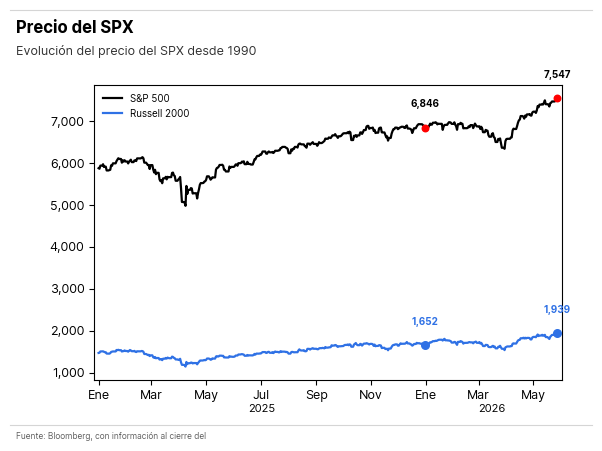

In [8]:


graph = Graph_mtplt(dataframe = data_indices_i)
graph.graph_line(
    tickers = "all",
    labels = ["S&P 500", "Russell 2000"],
    titles=dict(
        title="Precio del SPX",
        subtitle="Evolución del precio del SPX desde 1990"
    ),
    source = [f"Fuente: Bloomberg, con información al cierre del"],
    colors = ["black"],
    x_axis=dict(
        tick_step=2, 
        bbg_format=True,
        fmt="%Y",
        lim = ("2025-01-01", None)
        ),
    tag_dot={
        "PX_LAST-SPX INDEX": dict(
            x_values = ["last", pd.Timestamp("2025-12-31")],
            template = "{y_value:,.0f}",
            show="dot_tag",
            dot_color = "red",
            dot_size = 22,
        ),
        "PX_LAST-RUO INDEX": dict(
            x_values = ["last", pd.Timestamp("2025-12-31")],
            template = "{y_value:,.0f}",
            show="dot_tag",
        )
    },
    legend = dict(
        show = True
    ),
)
#graph._fig.subplots_adjust(top=0.85)

In [9]:
data_indices_j = data_indices_i.copy()
#data_indices_j = data_indices_j.resample("ME").last()
#data_indices_j = data_indices_j.tail(12)
data_indices_j

,PX_LAST-SPX INDEX,PX_LAST-RUO INDEX
Fecha,,
1996-06-04,672.56,277.813
1996-06-05,678.44,278.501
1996-06-06,673.03,275.541
1996-06-07,673.31,273.835
1996-06-08,673.31,273.835
...,...,...
2026-05-24,7473.47,1901.192
2026-05-25,7473.47,1901.192
2026-05-26,7519.12,1938.570


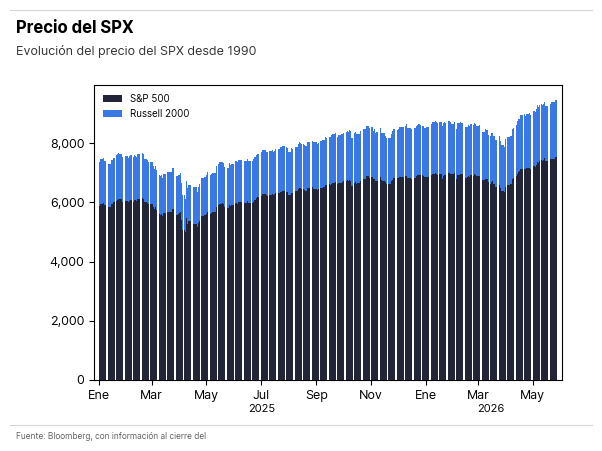

In [10]:
graph = Graph_mtplt(dataframe = data_indices_j)
graph.graph_bar(
    tickers = "all",
    labels = ["S&P 500", "Russell 2000"],
    titles=dict(
        title="Precio del SPX",
        subtitle="Evolución del precio del SPX desde 1990"
    ),
    source = [f"Fuente: Bloomberg, con información al cierre del"],
    colors = PALETA_COLORES,
    bar_mode = "time",
    stacked = True,
    grouped=False,
    show_values = False,
    value_fmt = ",.0f",
    x_axis=dict(
        tick_step=2,
        fontsize=8,
        bbg_format=True,
        fmt="%Y-%m",
        lim = ("2025-01-01", None)
        ),
)

['PX_LAST-SPX INDEX', 'PX_LAST-RUO INDEX']


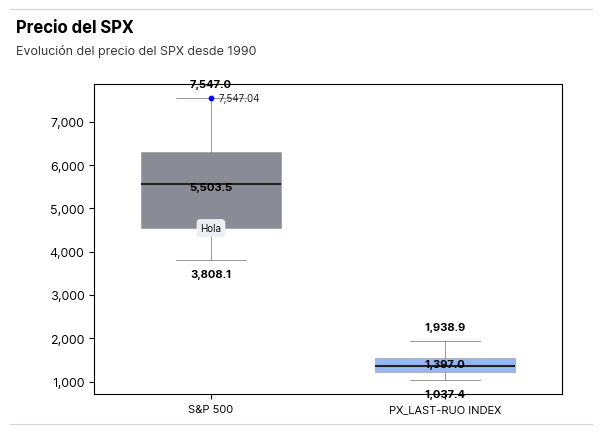

In [11]:
graph = Graph_mtplt(dataframe = data_indices_j)
graph.graph_box_whiskers(
    tickers = "all",
    labels = ["S&P 500"],
    titles=dict(
        title="Precio del SPX",
        subtitle="Evolución del precio del SPX desde 1990"
    ),
    x_axis=dict(
        lim =("2023-01-01", None)
    ),
    tag_dot={
        "PX_LAST-SPX INDEX":dict(
            x_values = "last",
            show="dot_tag",
            dot_size=10,
            dot_color = "blue"
        )
    }
)
graph.etiqueta_valor(x_value=1, y_value=4000, label="Hola", fontweight="normal")

In [22]:
df = pd.read_parquet("curve.parquet")

In [23]:
df = df.resample("ME").last()
df

,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
Date,,,,,,,,,,
1990-01-31,8.00,8.13,8.08,8.28,8.36,8.35,8.39,8.43,8.445,8.46
1990-02-28,8.04,8.14,8.12,8.43,8.45,8.44,8.54,8.51,8.525,8.54
1990-03-31,8.07,8.24,8.35,8.64,8.69,8.65,8.70,8.65,8.640,8.63
1990-04-30,8.07,8.44,8.58,8.96,9.05,9.04,9.06,9.04,9.020,9.00
1990-05-31,8.01,8.12,8.22,8.50,8.53,8.56,8.64,8.60,8.590,8.58
...,...,...,...,...,...,...,...,...,...,...
2026-02-28,3.67,3.60,3.48,3.38,3.39,3.51,3.72,3.97,4.570,4.64
2026-03-31,3.70,3.72,3.68,3.79,3.81,3.92,4.11,4.30,4.880,4.88
2026-04-30,3.68,3.71,3.72,3.88,3.91,4.02,4.20,4.40,4.970,4.98


In [ ]:
new_df = df.tail(2)
new_df.index = new_df.index.strftime("%d-%B")
new_df = new_df / 100.00
cols = new_df.columns.tolist()
date = new_df.index.tolist()
new_df_2 = new_df.tail(1)
new_df_2.index = ["mtd"]
new_df_3 = new_df.head(1)
new_df_3.index = ["mtd"]
new_df_4 = (new_df_2 - new_df_3) * 10000
new_df_4


,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
mtd,8.0,0.0,3.0,7.0,3.0,4.0,4.0,1.0,-1.0,-2.0


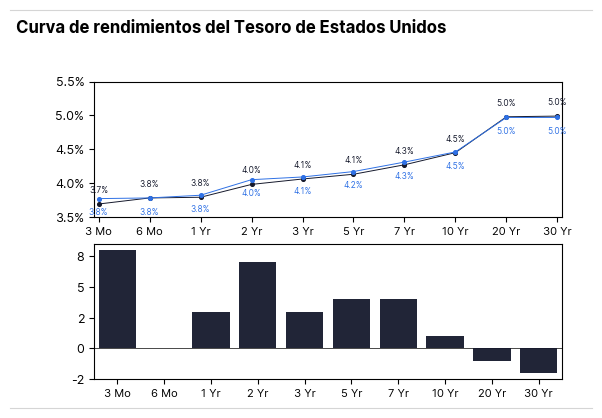

In [50]:
graph = Graph_mtplt([new_df.T,new_df_4.T])
graph.plot(nrows=2)
graph.graph_line(
    titles=dict(
        title = "Curva de rendimientos del Tesoro de Estados Unidos",
        subtitle = ""
    ),
    y_axis=dict(
        fmt=".1%",
        lim=(0.035,0.055)
    ),
    tag_dot={
        date[0]:dict(
            x_values=cols,
            show="tag_dot",
            template="{y_value:.1%}",
            loc_offset=(0,10),
            dot_size=7,
            fontsize=6,
            font_color=PALETA_COLORES[0]
        ),
        date[1]:dict(
            x_values=cols,
            show="tag_dot",
            template="{y_value:.1%}",
            loc_offset=(0,-10),
            dot_size=7,
            fontsize=6,
            font_color=PALETA_COLORES[1]
        )
    },
    lw=0.7
)
graph._set_axis(1)
graph.graph_bar(
    df_index=1,
    hlines=dict(
        y_values=0,
        linestyle="-",
        color="black"
    )
)